# 베이스 라인

In [3]:
!pip install -q gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 96.3 MB/s eta 0:00:00:00:0100:01


In [4]:
from gensim.models import Word2Vec, FastText
import torch
import torch.nn as nn
from torch.utils.data import Dataset
import numpy as np
from torch.utils.data import Dataset, DataLoader
from nltk.tokenize import word_tokenize
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [5]:
# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## 데이터 불러오기

In [6]:
news_data = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
texts = news_data.data     # 문서 내용
labels = news_data.target  # 레이블

In [7]:
print(f"Number of documents: {len(texts)}")
print(f"Sample document: \n{texts[0]}")
print(f"Unique labels: {set(labels)}")

Number of documents: 18846
Sample document: 


I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a lot of
fun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final
regular season game.          PENS RULE!!!


Unique labels: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)

In [ ]:
# 데이터 분할
train_inputs, test_inputs, train_targets, test_targets = train_test_split(texts, labels, test_size=0.2, random_state=42)

In [ ]:
import re
nltk.download('stopwords')
stop_words = stopwords.words('english')

# 텍스트 데이터 전처리
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    stop_words = set(stopwords.words('english'))
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# 데이터에 적용 (1)
train_inputs = [clean_text(text) for text in train_inputs]
test_inputs = [clean_text(text) for text in test_inputs]

# 단어 토큰화만 진행 (2)
# train_sentences = [word_tokenize(text) for text in train_inputs]
# test_sentences = [word_tokenize(text) for text in test_inputs]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


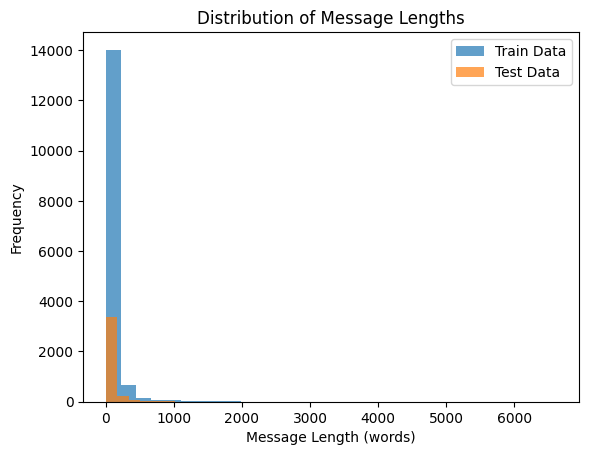

In [ ]:
# 메시지 길이 계산
train_lengths = [len(word_tokenize(msg)) for msg in train_inputs]
test_lengths = [len(word_tokenize(msg)) for msg in test_inputs]

# 히스토그램 시각화
plt.hist(train_lengths, bins=30, alpha=0.7, label='Train Data')
plt.hist(test_lengths, bins=30, alpha=0.7, label='Test Data')
plt.xlabel('Message Length (words)')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distribution of Message Lengths')
plt.show()

In [ ]:
# 평균, 최대값, 중간값 계산 및 출력
print("훈련 데이터 평균 길이:", np.mean(train_lengths))
print("훈련 데이터 최대 길이:", np.max(train_lengths))
print("훈련 데이터 95분위수 길이:", np.percentile(train_lengths, 95))

훈련 데이터 평균 길이: 93.84551605200318
훈련 데이터 최대 길이: 6620
훈련 데이터 95분위수 길이: 281.25


## Word2vec

In [ ]:
# 단어 토큰화
train_sentences = [word_tokenize(text) for text in train_inputs]
test_sentences = [word_tokenize(text) for text in test_inputs]

In [ ]:
# Word2Vec 모델 학습
word2vec_model = Word2Vec(sentences=train_sentences, vector_size=128, window=5, min_count=1, sg=1)
word2vec_matrix = np.zeros((len(word2vec_model.wv) + 1, 128))
word2idx_word2vec = {word: idx + 1 for idx, word in enumerate(word2vec_model.wv.index_to_key)}

for word, idx in word2idx_word2vec.items():
    word2vec_matrix[idx] = word2vec_model.wv[word]

In [ ]:
class TextEmbeddingDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_len):
        self.texts = texts
        self.labels = labels
        self.word2idx = word2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        tokens = word_tokenize(self.texts[idx])
        encoded = [self.word2idx.get(word, 0) for word in tokens]  # OOV 단어는 0
        if len(encoded) < self.max_len:
            encoded += [0] * (self.max_len - len(encoded))
        else:
            encoded = encoded[:self.max_len]
        return torch.tensor(encoded, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

In [ ]:
max_len = 280

# Word2Vec Dataset
train_dataset_word2vec = TextEmbeddingDataset(train_inputs, train_targets, word2idx_word2vec, max_len)
test_dataset_word2vec = TextEmbeddingDataset(test_inputs, test_targets, word2idx_word2vec, max_len)

# Word2Vec DataLoader
train_loader_word2vec = DataLoader(train_dataset_word2vec, batch_size=64, shuffle=True)
test_loader_word2vec = DataLoader(test_dataset_word2vec, batch_size=64, shuffle=False)

In [ ]:
def train(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for texts, labels in loader:
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(texts)  # 출력: (batch_size, 20)
        loss = criterion(outputs, labels)  # 레이블은 정수형 (0~19)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            outputs = model(texts)
            predictions = torch.argmax(outputs, dim=1)  # 가장 높은 확률의 인덱스
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    return correct / total

In [ ]:
class EmbeddingLSTM(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, output_dim, num_layers=2, dropout=0.5):
        super(EmbeddingLSTM, self).__init__()
        num_embeddings, embedding_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(torch.tensor(embedding_matrix, dtype=torch.float).to(device), freeze=False)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout, bidirectional=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        output = self.fc(hidden[-1])
        return output

In [ ]:
hidden_dim = 128
output_dim = len(set(labels))

In [ ]:
model_word2vec = EmbeddingLSTM(word2vec_matrix, hidden_dim, output_dim).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_word2vec.parameters(), lr=0.005)

for epoch in range(10):
    loss = train(model_word2vec, train_loader_word2vec, loss_fn, optimizer)
    print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

accuracy = evaluate(model_word2vec, test_loader_word2vec)
print(f"Test Accuracy (Word2Vec with LSTM): {accuracy:.4f}")

Epoch 1, Loss: 2.0305
Epoch 2, Loss: 1.1694
Epoch 3, Loss: 0.6997
Epoch 4, Loss: 0.4496
Epoch 5, Loss: 0.2950
Epoch 6, Loss: 0.2188
Epoch 7, Loss: 0.1697
Epoch 8, Loss: 0.1457
Epoch 9, Loss: 0.1318
Epoch 10, Loss: 0.1233
Test Accuracy (Word2Vec with LSTM): 0.6586


## FastText

In [ ]:
# FastText 모델 학습
fasttext_model = FastText(sentences=train_sentences, vector_size=128, window=5, min_count=1, sg=1)
fasttext_matrix = np.zeros((len(fasttext_model.wv) + 1, 128))

word2idx_fasttext = {word: idx + 1 for idx, word in enumerate(fasttext_model.wv.index_to_key)}

for word, idx in word2idx_fasttext.items():
    fasttext_matrix[idx] = fasttext_model.wv[word]

In [ ]:
# FastText Dataset
train_dataset_fasttext = TextEmbeddingDataset(train_inputs, train_targets, word2idx_fasttext, max_len)
test_dataset_fasttext = TextEmbeddingDataset(test_inputs, test_targets, word2idx_fasttext, max_len)

# FastText DataLoader
train_loader_fasttext = DataLoader(train_dataset_fasttext, batch_size=64, shuffle=True)
test_loader_fasttext = DataLoader(test_dataset_fasttext, batch_size=64, shuffle=False)

In [ ]:
model_fasttext = EmbeddingLSTM(fasttext_matrix, hidden_dim, output_dim).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_fasttext.parameters(), lr=0.005)

for epoch in range(10):
    loss = train(model_fasttext, train_loader_fasttext, loss_fn, optimizer)
    print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

accuracy = evaluate(model_fasttext, test_loader_fasttext)
print(f"Test Accuracy (FastText with LSTM): {accuracy:.4f}")

Epoch 1, Loss: 1.9967
Epoch 2, Loss: 1.1477
Epoch 3, Loss: 0.7490
Epoch 4, Loss: 0.4946
Epoch 5, Loss: 0.3448
Epoch 6, Loss: 0.2607
Epoch 7, Loss: 0.2012
Epoch 8, Loss: 0.1671
Epoch 9, Loss: 0.1488
Epoch 10, Loss: 0.1382
Test Accuracy (FastText with LSTM): 0.6650


## GloVe

In [ ]:
import os
import urllib.request

# GloVe 다운로드 및 임베딩 로드
GLOVE_URL = "https://nlp.stanford.edu/data/glove.6B.zip"
GLOVE_ZIP = "glove.6B.zip"
GLOVE_FILE = "glove.6B.200d.txt"

if not os.path.exists(GLOVE_FILE):
    print("Downloading GloVe embeddings...")
    urllib.request.urlretrieve(GLOVE_URL, GLOVE_ZIP)
    import zipfile
    with zipfile.ZipFile(GLOVE_ZIP, 'r') as zip_ref:
        zip_ref.extractall()
    print("GloVe embeddings downloaded and extracted.")
else:
    print("GloVe embeddings already available.")

GloVe embeddings downloaded and extracted.


In [ ]:
embedding_dim = 200  # GloVe 임베딩 차원 설정
glove_embeddings = {}

with open(GLOVE_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coeffs = np.asarray(values[1:], dtype='float32')
        glove_embeddings[word] = coeffs

In [ ]:
len(glove_embeddings)

400000

In [ ]:
# GloVe word2idx 생성
word2idx_glove = {word: idx + 1 for idx, word in enumerate(glove_embeddings.keys())}
glove_matrix = np.zeros((len(word2idx_glove) + 1, embedding_dim))

for word, idx in word2idx_glove.items():
    embedding_vector = glove_embeddings.get(word)
    if embedding_vector is not None:
        glove_matrix[idx] = embedding_vector

In [ ]:
# GloVe Dataset
train_dataset_glove = TextEmbeddingDataset(train_inputs, train_targets, word2idx_glove, max_len)
test_dataset_glove = TextEmbeddingDataset(test_inputs, test_targets, word2idx_glove, max_len)

# GloVe DataLoader
train_loader_glove = DataLoader(train_dataset_glove, batch_size=32, shuffle=True)
test_loader_glove = DataLoader(test_dataset_glove, batch_size=32, shuffle=False)

In [ ]:
model_glove = EmbeddingLSTM(glove_matrix, hidden_dim, output_dim).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_glove.parameters(), lr=0.005)

for epoch in range(10):
    loss = train(model_glove, train_loader_glove, loss_fn, optimizer)
    print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

accuracy = evaluate(model_glove, test_loader_glove)
print(f"Test Accuracy (GloVe with LSTM): {accuracy:.4f}")

Epoch 1, Loss: 1.7441
Epoch 2, Loss: 1.0268
Epoch 3, Loss: 0.6785
Epoch 4, Loss: 0.4661
Epoch 5, Loss: 0.3448
Epoch 6, Loss: 0.2650
Epoch 7, Loss: 0.2335
Epoch 8, Loss: 0.2107
Epoch 9, Loss: 0.1839
Epoch 10, Loss: 0.1875
Test Accuracy (GloVe with LSTM): 0.6626


# 미션 10

In [1]:
!pip install -q gensim


In [2]:
from gensim.models import Word2Vec, FastText
import torch
import torch.nn as nn
from torch.utils.data import Dataset
import numpy as np
from torch.utils.data import Dataset, DataLoader
from nltk.tokenize import word_tokenize
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
news_data = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
texts = news_data.data     # 문서 내용
labels = news_data.target  # 레이블

## 데이터 EDA

In [5]:
print(f"Number of documents: {len(texts)}")
print(f"Sample document: \n{texts[0]}")
print(f"Unique labels: {set(labels)}")

Number of documents: 18846
Sample document: 


I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a lot of
fun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final
regular season game.          PENS RULE!!!


Unique labels: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)

### 클래스 불균형 확인

클래스별 데이터 개수
alt.atheism                 799
comp.graphics               973
comp.os.ms-windows.misc     985
comp.sys.ibm.pc.hardware    982
comp.sys.mac.hardware       963
comp.windows.x              988
misc.forsale                975
rec.autos                   990
rec.motorcycles             996
rec.sport.baseball          994
rec.sport.hockey            999
sci.crypt                   991
sci.electronics             984
sci.med                     990
sci.space                   987
soc.religion.christian      997
talk.politics.guns          910
talk.politics.mideast       940
talk.politics.misc          775
talk.religion.misc          628
Name: count, dtype: int64


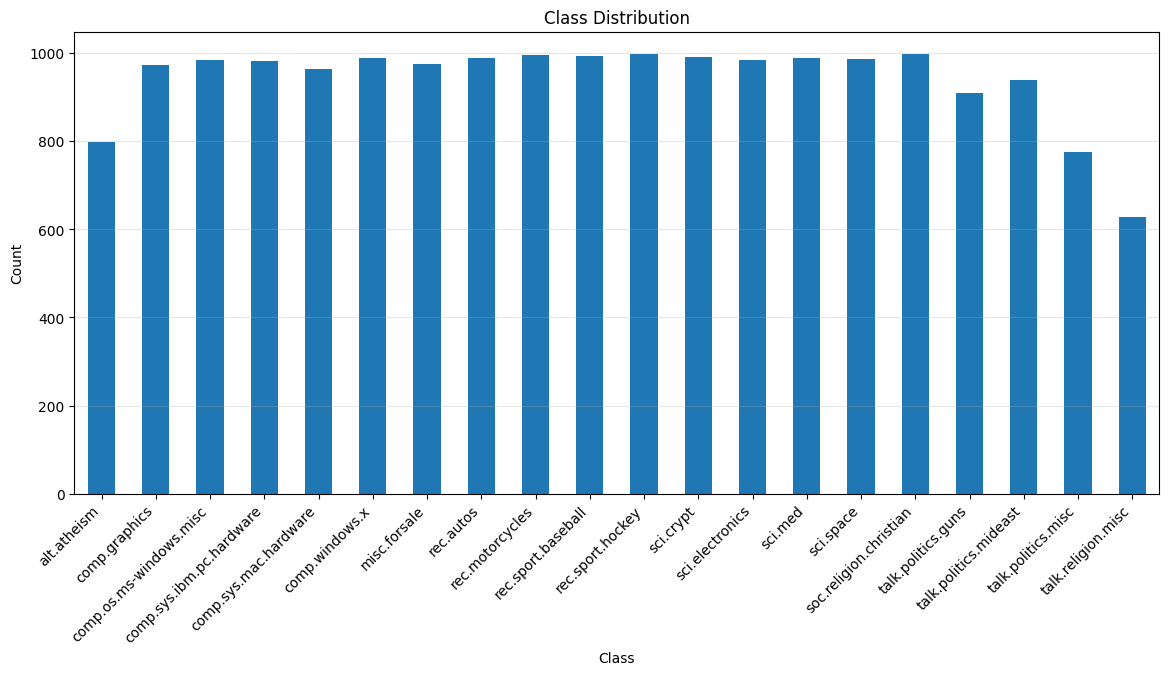

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 클래스 이름으로 변환
label_names = [news_data.target_names[label] for label in labels]

# 분포 확인
label_counts = pd.Series(label_names).value_counts().sort_index()

print("클래스별 데이터 개수")
print(label_counts)

# 그래프
plt.figure(figsize=(14, 6))
label_counts.plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.show()


대체로 클래스가 균형을 이루고 있지만 특정 몇몇 소수 클래스가 존재함

### 노이즈 확인

In [7]:
# 4. 노이즈 패턴 확인
import re
import numpy as np

url_count = sum(bool(re.search(r'http|www', text.lower())) for text in texts)
email_count = sum(bool(re.search(r'@', text)) for text in texts)
digit_count = sum(bool(re.search(r'\d', text)) for text in texts)
special_char_count = sum(bool(re.search(r'[^a-zA-Z0-9\s]', text)) for text in texts)

print(f"전체 문서 수: {len(texts)}")
print(f"URL 포함 문서 비율: {url_count / len(texts):.2%}")
print(f"이메일(@) 포함 문서 비율: {email_count / len(texts):.2%}")
print(f"숫자 포함 문서 비율: {digit_count / len(texts):.2%}")
print(f"특수문자 포함 문서 비율: {special_char_count / len(texts):.2%}")


전체 문서 수: 18846
URL 포함 문서 비율: 0.08%
이메일(@) 포함 문서 비율: 15.49%
숫자 포함 문서 비율: 57.41%
특수문자 포함 문서 비율: 97.01%


url이나 이메일은 특수 토큰으로 치환에서 vocab 수는 줄이고 패턴 정보는 유지하는 식으로 진행하려 함

### 이상치 확인

In [8]:
# 5. 이상치 샘플 직접 보기 (가장 짧은 문서 / 가장 긴 문서)
text_lengths = [len(text.split()) for text in texts]

short_idx = sorted(range(len(text_lengths)), key=lambda i: text_lengths[i])[:5]
long_idx = sorted(range(len(text_lengths)), key=lambda i: text_lengths[i], reverse=True)[:5]

print("가장 짧은 문서 5개")
for i in short_idx:
    print(f"\n[인덱스 {i}] 길이: {text_lengths[i]}, label: {news_data.target_names[labels[i]]}")
    print(texts[i][:1000])
    print("-" * 80)

print("\n가장 긴 문서 5개")
for i in long_idx:
    print(f"\n[인덱스 {i}] 길이: {text_lengths[i]}, label: {news_data.target_names[labels[i]]}")
    print(texts[i][:1000])
    print("-" * 80)


가장 짧은 문서 5개

[인덱스 91] 길이: 0, label: talk.religion.misc

--------------------------------------------------------------------------------

[인덱스 104] 길이: 0, label: talk.religion.misc

--------------------------------------------------------------------------------

[인덱스 127] 길이: 0, label: rec.sport.hockey

--------------------------------------------------------------------------------

[인덱스 135] 길이: 0, label: talk.politics.mideast

--------------------------------------------------------------------------------

[인덱스 161] 길이: 0, label: comp.sys.ibm.pc.hardware

--------------------------------------------------------------------------------

가장 긴 문서 5개

[인덱스 17014] 길이: 11765, label: sci.electronics
Since electrical wiring questions do turn up from time to time on
sci.electronics (and the answers aren't always apparent, even to those skilled
in electronics), I am hijacking the following FAQ and posting a copy here. 
I've asked the writers to cross-post to sci.electronics in the future. 


짧은 문서는 빈 문서가 출력돼서 전처리 후 다시 확인해봐야하고 킨 문서의 경우 필요없는 장식이 많아서 전처리가 필요함

### 중복 결측 확인

In [9]:
# 6. 중복 / 결측 확인
import pandas as pd

df_text = pd.DataFrame({
    "text": texts,
    "label": labels
})

empty_count = sum((text is None) or (str(text).strip() == "") for text in texts)
duplicate_count = df_text.duplicated(subset=["text"]).sum()

print(f"빈 문서 수: {empty_count}")
print(f"중복 문서 수(텍스트 기준): {duplicate_count}")


빈 문서 수: 515
중복 문서 수(텍스트 기준): 559


중복 문서와 빈 문서 수가 많아서 전처리 필요함.

## 전처리

In [10]:
import re
nltk.download('stopwords')
stop_words = stopwords.words('english')

# 1. 소문자화
def to_lower(text):
    return text.lower()

# 2. URL / 이메일 / 숫자 치환
def replace_special_patterns(text):
    text = re.sub(r'http\S+|www\S+', ' URLTOKEN ', text)
    text = re.sub(r'\S+@\S+', ' EMAILTOKEN ', text)
    text = re.sub(r'\b\d+\b', ' NUMTOKEN ', text)
    return text

# 3. 장식 줄 제거
def remove_meta_and_ascii_lines(text):
    cleaned_lines = []

    for line in text.split('\n'):
        line = line.strip()

        # 빈 줄은 일단 넘김
        if not line:
            continue

        # 메타데이터 줄 제거
        if re.match(r'^(from|subject|organization|reply-to|date|message-id|archive-name|last-modified|newsgroups|lines|summary|expires|followup-to)\s*:', line.lower()):
            continue

        # 장식용 구분선 제거
        if re.fullmatch(r'[-=+_*~|]{5,}', line):
            continue

        # 박스 테두리 문자 제거 (내용은 남김)
        line = re.sub(r'^\|+', '', line)
        line = re.sub(r'\|+$', '', line)
        line = re.sub(r'^\++', '', line)
        line = re.sub(r'\++$', '', line)

        line = line.strip()

        if line:
            cleaned_lines.append(line)

    return ' '.join(cleaned_lines)

# 4. 불필요한 특수문자 정리 + 공백 정리
def clean_special_characters(text):
    # 토큰으로 남길 단어와 공백만 유지
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # 공백 여러 개를 하나로
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# 5. 토큰화
def tokenize_text(text):
    return word_tokenize(text)

# 6. 불용어 제거
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
# 전체 전처리 함수
def clean_text(text, remove_stopword=True):
    text = to_lower(text)
    text = replace_special_patterns(text)
    text = remove_meta_and_ascii_lines(text)
    text = clean_special_characters(text)

    tokens = tokenize_text(text)

    if remove_stopword:
        tokens = remove_stopwords(tokens)

    return ' '.join(tokens)


In [12]:
import pandas as pd

# 원본 데이터프레임 생성
df = pd.DataFrame({
    "text": texts,
    "label": labels
})

print("정제 전 데이터 개수:", len(df))

# 1. 명백한 결측치 제거
df = df.dropna(subset=["text"])

# 2. 문자열로 변환 후 양쪽 공백 제거
df["text"] = df["text"].astype(str).str.strip()

# 3. 완전 빈 문서 제거
df = df[df["text"] != ""]

# 4. 완전 중복 문서 제거 (텍스트 기준)
df = df.drop_duplicates(subset=["text"])

print("정제 후 데이터 개수:", len(df))
print("제거된 데이터 개수:", len(texts) - len(df))

# 다시 리스트 형태로 복원
texts = df["text"].tolist()
labels = df["label"].tolist()


정제 전 데이터 개수: 18846
정제 후 데이터 개수: 18262
제거된 데이터 개수: 584


In [13]:
train_inputs, test_inputs, train_targets, test_targets = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

raw_train_inputs = train_inputs.copy()
raw_test_inputs = test_inputs.copy()

train_inputs = [clean_text(text) for text in train_inputs]
test_inputs = [clean_text(text) for text in test_inputs]


## 전처리 후 eda

train 평균 길이: 117.45581490861798
train 중앙값 길이: 46.0
train 최대 길이: 19809
train 95분위수 길이: 320.0
train 99분위수 길이: 1179.6800000000003


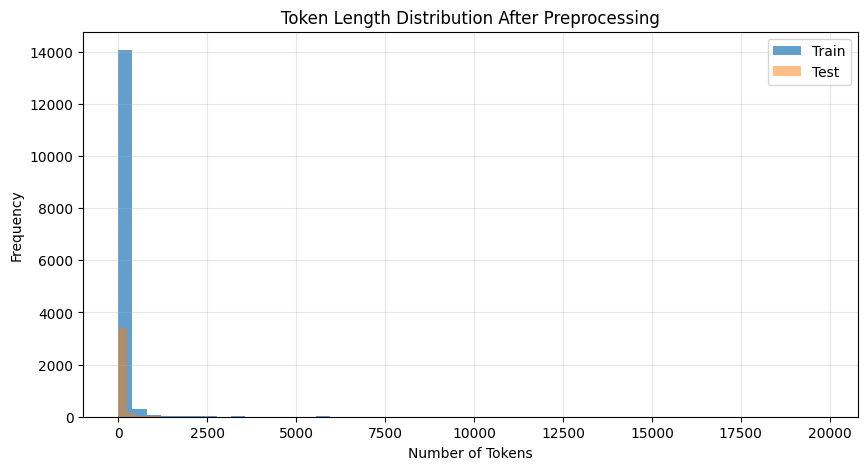

In [14]:
# 1. 전처리 후 길이 분포
import numpy as np
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize

train_lengths = [len(word_tokenize(text)) for text in train_inputs]
test_lengths = [len(word_tokenize(text)) for text in test_inputs]

print("train 평균 길이:", np.mean(train_lengths))
print("train 중앙값 길이:", np.median(train_lengths))
print("train 최대 길이:", np.max(train_lengths))
print("train 95분위수 길이:", np.percentile(train_lengths, 95))
print("train 99분위수 길이:", np.percentile(train_lengths, 99))

plt.figure(figsize=(10, 5))
plt.hist(train_lengths, bins=50, alpha=0.7, label="Train")
plt.hist(test_lengths, bins=50, alpha=0.5, label="Test")
plt.title("Token Length Distribution After Preprocessing")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [15]:
# 2. 빈 문서 / 너무 짧은 문서 확인
empty_docs = [i for i, text in enumerate(train_inputs) if len(text.strip()) == 0]
short_docs = [i for i, text in enumerate(train_inputs) if 0 < len(text.split()) <= 3]

print(f"빈 문서 개수: {len(empty_docs)}")
print(f"너무 짧은 문서 개수(1~3토큰): {len(short_docs)}")

print("\n빈 문서 예시 인덱스 5개:", empty_docs[:5])

print("\n너무 짧은 문서 예시 5개")
for i in short_docs[:5]:
    print(f"[인덱스 {i}] 길이: {len(train_inputs[i].split())}")
    print(train_inputs[i])
    print("-" * 60)


빈 문서 개수: 16
너무 짧은 문서 개수(1~3토큰): 187

빈 문서 예시 인덱스 5개: [1760, 2315, 2464, 2666, 2944]

너무 짧은 문서 예시 5개
[인덱스 72] 길이: 2
good luck
------------------------------------------------------------
[인덱스 325] 길이: 1
unfortunately
------------------------------------------------------------
[인덱스 336] 길이: 3
bet runway nearby
------------------------------------------------------------
[인덱스 365] 길이: 1
system
------------------------------------------------------------
[인덱스 466] 길이: 2
woof woof
------------------------------------------------------------


In [16]:
# 3. 전처리 전후 비교
for i in range(5):
    print(f"[샘플 {i+1}]")
    print("전처리 전:")
    print(raw_train_inputs[i][:700])
    print("\n전처리 후:")
    print(train_inputs[i][:700])
    print("=" * 80)


[샘플 1]
전처리 전:
Maine 5, LSSU 4.

전처리 후:
maine NUMTOKEN lssu NUMTOKEN
[샘플 2]
전처리 전:
Highway 12 is a great road.  Be sure to stop by the Anasazi (sp) village
museum near Boulder Creek.  Interesting lifestyle :-).  The views of Dixie 
National Forest are stunning.

전처리 후:
highway NUMTOKEN great road sure stop anasazi sp village museum near boulder creek interesting lifestyle views dixie national forest stunning
[샘플 3]
전처리 전:
Hi I'm new to imaging, and my advisor and I would like to 
do some 3D reconstructions.

We take slides (biological), and image them on a 486.  Then
the software allows us to trace the outline of the objects 
we want to save.  The outlines are stored as a TIFF file.

We would like to convert a group of these outlines into a 
3D image.  We are unsure as to where to begin.  Someone mentioned
that if we could convert the TIFF into a vector format then 
we could view them in Autocad.

Any help would be greatly appreciated.

전처리 후:
hi new imaging advisor would like reconstru

In [17]:
# 4. 상위 빈출 단어 확인
from collections import Counter

all_tokens = []
for text in train_inputs:
    all_tokens.extend(word_tokenize(text))

token_counts = Counter(all_tokens)

print("상위 빈출 단어 30개")
print(token_counts.most_common(30))


상위 빈출 단어 30개
[('NUMTOKEN', 137896), ('ax', 51722), ('EMAILTOKEN', 11939), ('x', 10015), ('one', 8381), ('would', 8244), ('q', 6309), ('g', 5553), ('f', 5321), ('like', 5227), ('b', 5126), ('people', 5123), ('r', 4905), ('v', 4753), ('know', 4738), ('get', 4681), ('p', 4597), ('w', 4525), ('also', 4375), ('c', 4370), ('e', 4183), ('u', 4077), ('think', 4043), ('use', 3955), ('time', 3936), ('max', 3810), ('n', 3450), ('could', 3303), ('well', 3270), ('new', 3243)]


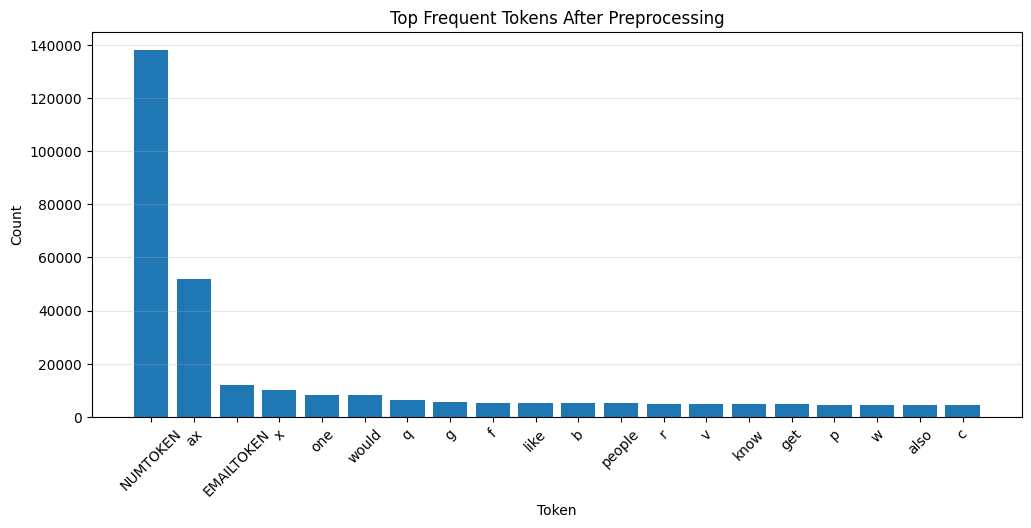

In [18]:
# 상위 20개 단어 시각화
top_k = 20
top_words = token_counts.most_common(top_k)

words = [w for w, c in top_words]
counts = [c for w, c in top_words]

plt.figure(figsize=(12, 5))
plt.bar(words, counts)
plt.title("Top Frequent Tokens After Preprocessing")
plt.xlabel("Token")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()


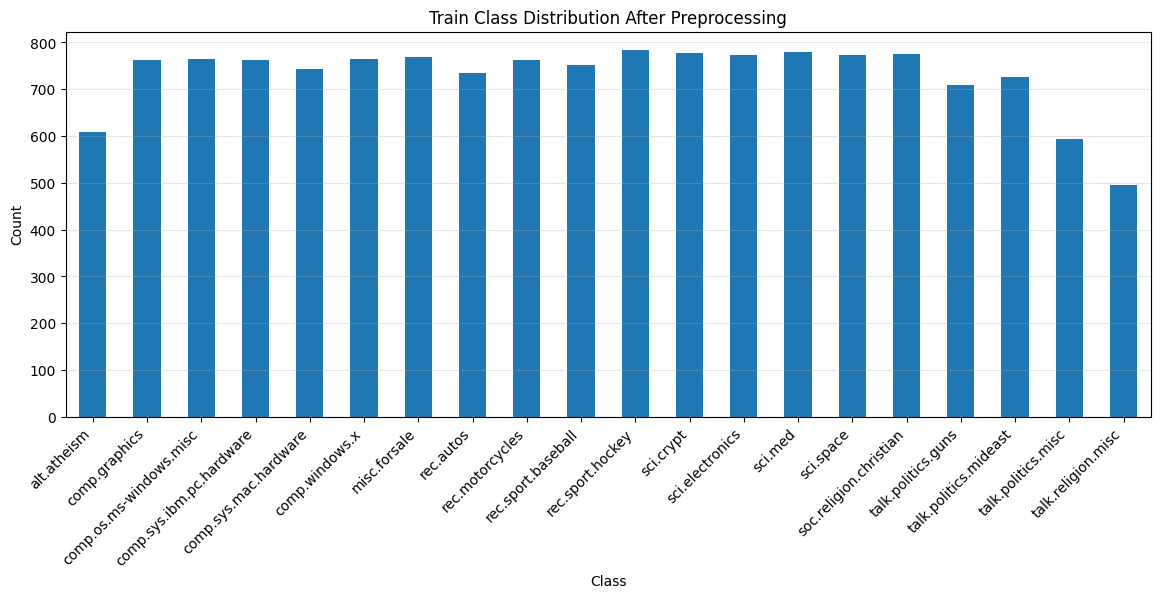

In [19]:
# train data 클래스 분포 시각화
train_label_names = [news_data.target_names[label] for label in train_targets]
pd.Series(train_label_names).value_counts().sort_index().plot(kind='bar', figsize=(14,5))
plt.title("Train Class Distribution After Preprocessing")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.show()


# 임베딩 및 분류

## Word2vec

In [20]:
# 단어 토큰화
train_sentences = [word_tokenize(text) for text in train_inputs]
test_sentences = [word_tokenize(text) for text in test_inputs]

In [21]:
PAD_IDX = 0
UNK_IDX = 1
embedding_dim = 128

# Word2Vec 모델 학습
word2vec_model = Word2Vec(
    sentences=train_sentences,
    vector_size=embedding_dim,
    window=5,
    min_count=1,
    sg=1
)

# PAD, UNK 때문에 +2
word2vec_matrix = np.zeros((len(word2vec_model.wv) + 2, embedding_dim))

# UNK는 랜덤 벡터로 초기화
word2vec_matrix[UNK_IDX] = np.random.normal(0, 0.1, embedding_dim)

# 실제 단어들은 2번 index부터 시작
word2idx_word2vec = {
    word: idx + 2
    for idx, word in enumerate(word2vec_model.wv.index_to_key)
}

for word, idx in word2idx_word2vec.items():
    word2vec_matrix[idx] = word2vec_model.wv[word]


In [22]:
class TextEmbeddingDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_len, unk_idx=1, pad_idx=0):
        self.texts = texts
        self.labels = labels
        self.word2idx = word2idx
        self.max_len = max_len
        self.unk_idx = unk_idx
        self.pad_idx = pad_idx

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        tokens = word_tokenize(self.texts[idx])

        # vocab에 없는 단어는 UNK
        encoded = [self.word2idx.get(word, self.unk_idx) for word in tokens]

        # 짧으면 PAD로 채우기
        if len(encoded) < self.max_len:
            encoded += [self.pad_idx] * (self.max_len - len(encoded))
        else:
            encoded = encoded[:self.max_len]

        return torch.tensor(encoded, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

In [23]:
from torch.utils.data import WeightedRandomSampler
import numpy as np
import torch

# train_targets 기준 클래스별 개수 확인
class_counts = np.bincount(train_targets)
print("클래스별 개수:", class_counts)

# 클래스 개수의 역수를 weight로 사용
class_weights = 1.0 / class_counts

# 각 샘플마다 자기 클래스에 해당하는 weight 부여
sample_weights = np.array([class_weights[label] for label in train_targets])

# torch tensor로 변환
sample_weights = torch.DoubleTensor(sample_weights)

# WeightedRandomSampler 생성
weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

클래스별 개수: [609 762 764 762 744 764 768 734 762 751 784 778 774 779 774 775 710 726
 593 496]


클래스 불균형 해소를 위해 WeightedRandomSampler 적용

In [24]:
max_len = 280

# Word2Vec Dataset
train_dataset_word2vec = TextEmbeddingDataset(
    train_inputs,
    train_targets,
    word2idx_word2vec,
    max_len,
    unk_idx=UNK_IDX,
    pad_idx=PAD_IDX
)

test_dataset_word2vec = TextEmbeddingDataset(
    test_inputs,
    test_targets,
    word2idx_word2vec,
    max_len,
    unk_idx=UNK_IDX,
    pad_idx=PAD_IDX
)




# Word2Vec DataLoader
train_loader_word2vec = DataLoader(
    train_dataset_word2vec,
    batch_size=64,
    sampler=weighted_sampler
)

test_loader_word2vec = DataLoader(test_dataset_word2vec, batch_size=64, shuffle=False)

In [25]:
def train(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for texts, labels in loader:
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(texts)  # 출력: (batch_size, 20)
        loss = criterion(outputs, labels)  # 레이블은 정수형 (0~19)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            outputs = model(texts)
            predictions = torch.argmax(outputs, dim=1)  # 가장 높은 확률의 인덱스
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    return correct / total

In [26]:
class EmbeddingLSTM(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, output_dim, num_layers=2, dropout=0.5):
        super(EmbeddingLSTM, self).__init__()
        num_embeddings, embedding_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(torch.tensor(embedding_matrix, dtype=torch.float).to(device), freeze=False)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout, bidirectional=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        output = self.fc(hidden[-1])
        return output

In [27]:
hidden_dim = 128
output_dim = len(set(labels))

In [28]:
model_word2vec = EmbeddingLSTM(word2vec_matrix, hidden_dim, output_dim).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_word2vec.parameters(), lr=0.005)

num_epochs = 10

train_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(num_epochs):
    loss = train(model_word2vec, train_loader_word2vec, loss_fn, optimizer)

    train_acc = evaluate(model_word2vec, train_loader_word2vec)
    test_acc = evaluate(model_word2vec, test_loader_word2vec)

    train_losses.append(loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(
        f"Epoch {epoch+1}, "
        f"Loss: {loss:.4f}, "
        f"Train Accuracy: {train_acc:.4f}, "
        f"Test Accuracy: {test_acc:.4f}"
    )



Epoch 1, Loss: 1.7786, Train Accuracy: 0.5444, Test Accuracy: 0.5053
Epoch 2, Loss: 0.9897, Train Accuracy: 0.7533, Test Accuracy: 0.6433
Epoch 3, Loss: 0.5919, Train Accuracy: 0.8679, Test Accuracy: 0.6852
Epoch 4, Loss: 0.3937, Train Accuracy: 0.9131, Test Accuracy: 0.6931
Epoch 5, Loss: 0.2468, Train Accuracy: 0.9411, Test Accuracy: 0.6994
Epoch 6, Loss: 0.1986, Train Accuracy: 0.9613, Test Accuracy: 0.7002
Epoch 7, Loss: 0.1292, Train Accuracy: 0.9709, Test Accuracy: 0.6970
Epoch 8, Loss: 0.1002, Train Accuracy: 0.9777, Test Accuracy: 0.7016
Epoch 9, Loss: 0.0723, Train Accuracy: 0.9832, Test Accuracy: 0.7019
Epoch 10, Loss: 0.0569, Train Accuracy: 0.9864, Test Accuracy: 0.6992


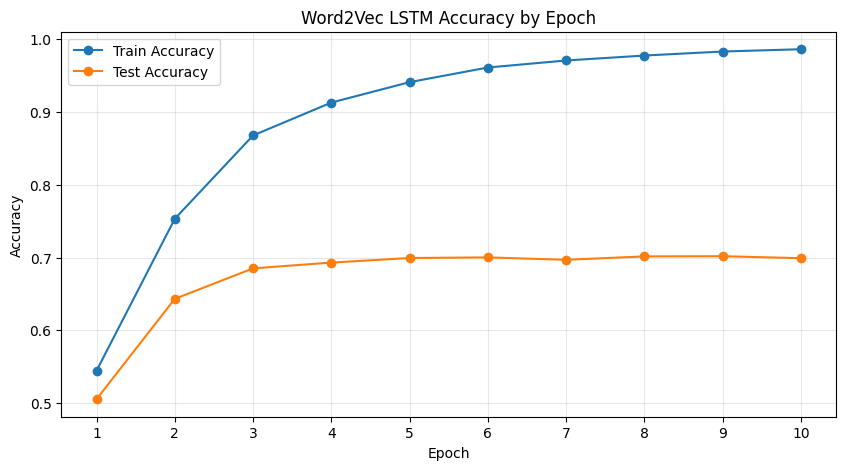

In [29]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_accuracies, marker='o', label="Train Accuracy")
plt.plot(epochs, test_accuracies, marker='o', label="Test Accuracy")

plt.title("Word2Vec LSTM Accuracy by Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


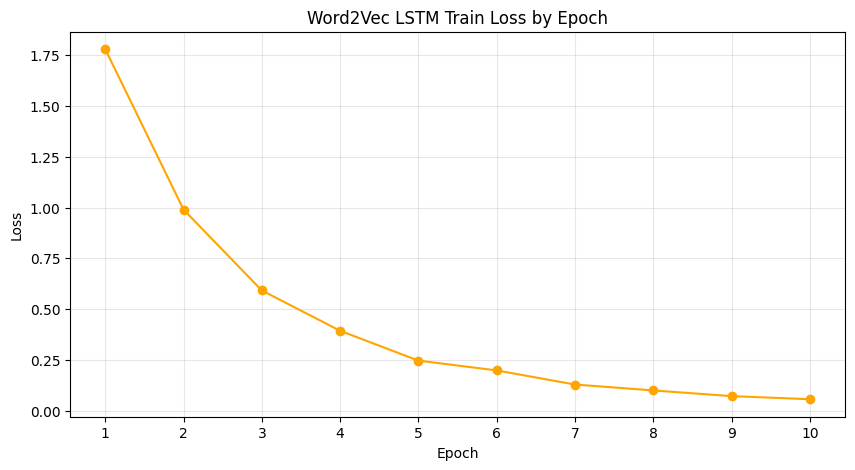

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, marker='o', color='orange')

plt.title("Word2Vec LSTM Train Loss by Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.grid(alpha=0.3)
plt.show()


### 평가 지표

In [31]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


In [32]:
def get_predictions(model, loader, device):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for texts, labels in loader:
            texts = texts.to(device)
            labels = labels.to(device)

            outputs = model(texts)
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return np.array(y_true), np.array(y_pred)


In [33]:
y_true_w2v, y_pred_w2v = get_predictions(
    model_word2vec,
    test_loader_word2vec,
    device
)

In [34]:
accuracy = accuracy_score(y_true_w2v, y_pred_w2v)
macro_precision = precision_score(y_true_w2v, y_pred_w2v, average='macro', zero_division=0)
macro_recall = recall_score(y_true_w2v, y_pred_w2v, average='macro', zero_division=0)
macro_f1 = f1_score(y_true_w2v, y_pred_w2v, average='macro', zero_division=0)

weighted_precision = precision_score(y_true_w2v, y_pred_w2v, average='weighted', zero_division=0)
weighted_recall = recall_score(y_true_w2v, y_pred_w2v, average='weighted', zero_division=0)
weighted_f1 = f1_score(y_true_w2v, y_pred_w2v, average='weighted', zero_division=0)

print(f"Accuracy          : {accuracy:.4f}")
print(f"Macro Precision   : {macro_precision:.4f}")
print(f"Macro Recall      : {macro_recall:.4f}")
print(f"Macro F1          : {macro_f1:.4f}")
print(f"Weighted Precision: {weighted_precision:.4f}")
print(f"Weighted Recall   : {weighted_recall:.4f}")
print(f"Weighted F1       : {weighted_f1:.4f}")


Accuracy          : 0.6992
Macro Precision   : 0.7053
Macro Recall      : 0.6953
Macro F1          : 0.6937
Weighted Precision: 0.7165
Weighted Recall   : 0.6992
Weighted F1       : 0.7020


In [35]:
target_names = news_data.target_names

print(classification_report(
    y_true_w2v,
    y_pred_w2v,
    target_names=target_names,
    zero_division=0
))

                          precision    recall  f1-score   support

             alt.atheism       0.55      0.56      0.55       170
           comp.graphics       0.68      0.66      0.67       189
 comp.os.ms-windows.misc       0.74      0.67      0.70       179
comp.sys.ibm.pc.hardware       0.59      0.65      0.62       198
   comp.sys.mac.hardware       0.71      0.77      0.74       183
          comp.windows.x       0.83      0.85      0.84       199
            misc.forsale       0.72      0.67      0.69       175
               rec.autos       0.75      0.76      0.75       202
         rec.motorcycles       0.68      0.67      0.67       205
      rec.sport.baseball       0.85      0.76      0.80       206
        rec.sport.hockey       0.89      0.83      0.86       191
               sci.crypt       0.80      0.84      0.82       184
         sci.electronics       0.64      0.61      0.62       179
                 sci.med       0.69      0.84      0.76       177
         

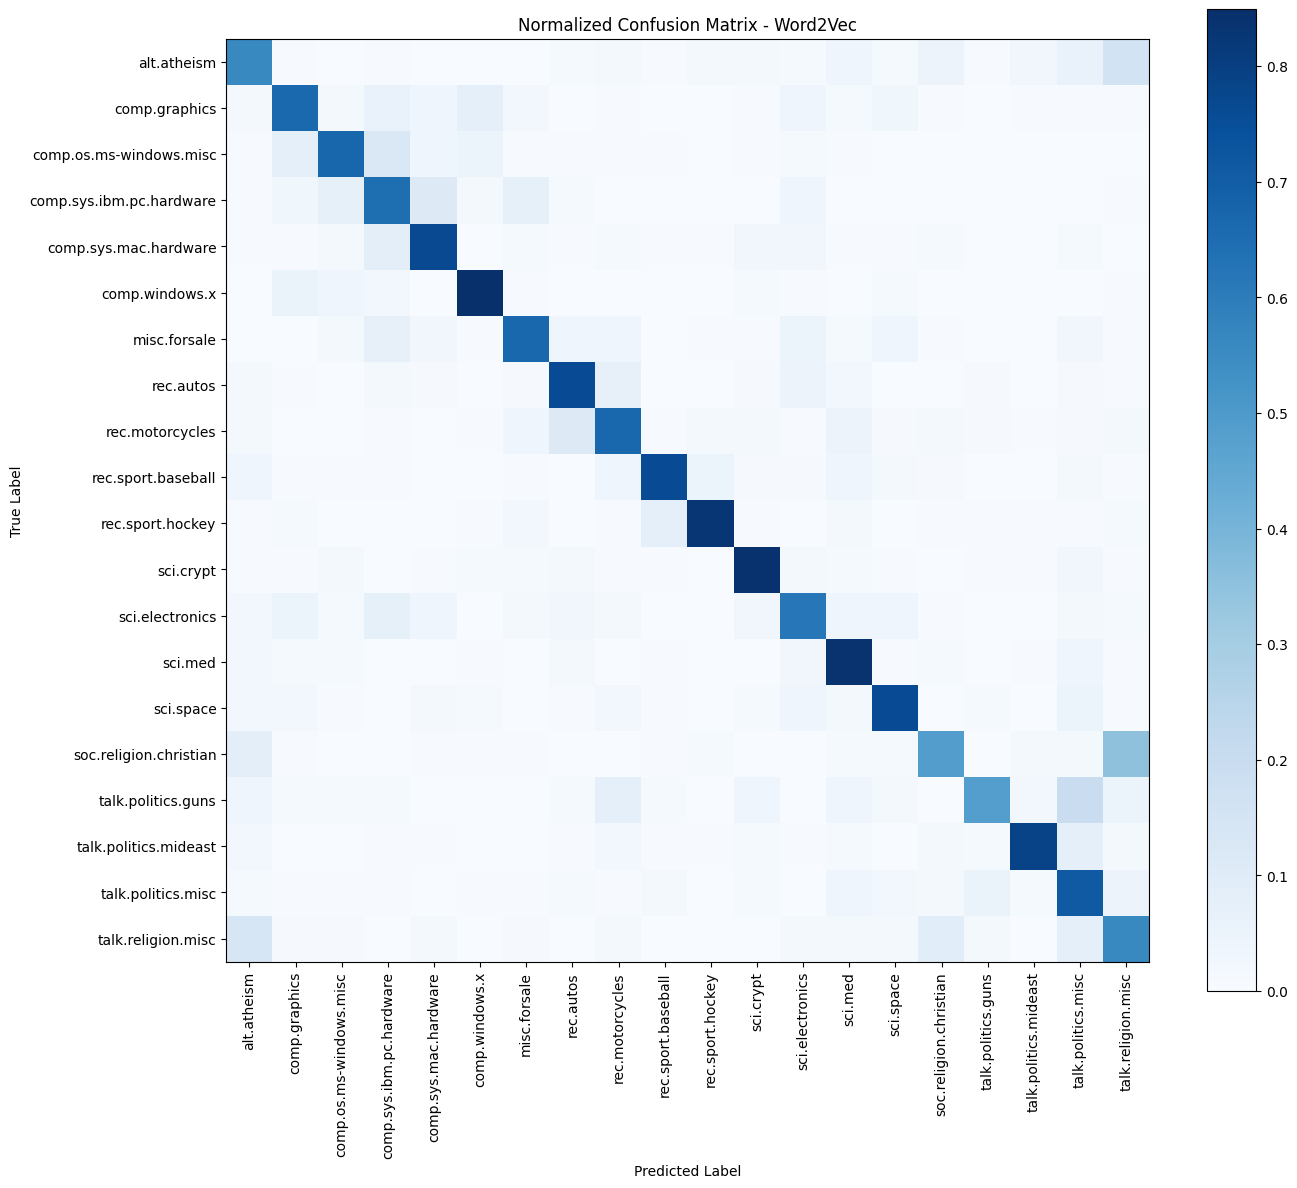

In [37]:
cm = confusion_matrix(y_true_w2v, y_pred_w2v)

cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)

plt.figure(figsize=(14, 12))
plt.imshow(cm_norm, interpolation='nearest', cmap='Blues')
plt.title("Normalized Confusion Matrix - Word2Vec")
plt.colorbar()

tick_marks = np.arange(len(target_names))
plt.xticks(tick_marks, target_names, rotation=90)
plt.yticks(tick_marks, target_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [62]:
def predict_one_text(text, model, word2idx, max_len, target_names, device, already_cleaned=False, unk_idx=1, pad_idx=0):
    model.eval()

    if already_cleaned:
        cleaned_text = text
    else:
        cleaned_text = clean_text(text)

    tokens = word_tokenize(cleaned_text)
    encoded = [word2idx.get(word, unk_idx) for word in tokens]

    if len(encoded) < max_len:
        encoded += [pad_idx] * (max_len - len(encoded))
    else:
        encoded = encoded[:max_len]

    input_tensor = torch.tensor(encoded, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        pred_prob = probs[0][pred_idx].item()

    return pred_idx, target_names[pred_idx], pred_prob, cleaned_text


In [63]:
for sample_idx in range(5):
    pred_idx, pred_label, pred_prob, cleaned_text = predict_one_text(
        test_inputs[sample_idx],
        model_word2vec,
        word2idx_word2vec,
        max_len,
        news_data.target_names,
        device,
        already_cleaned=True,
        unk_idx=UNK_IDX,
        pad_idx=PAD_IDX
    )

    true_label = news_data.target_names[test_targets[sample_idx]]

    print(f"[테스트 샘플 {sample_idx}]")
    print(f"실제 라벨: {true_label}")
    print(f"예측 라벨: {pred_label}")
    print(f"확신도: {pred_prob:.4f}")
    print("전처리된 텍스트:")
    print(cleaned_text[:500])
    print("-" * 80)


[테스트 샘플 0]
실제 라벨: talk.politics.mideast
예측 라벨: talk.politics.mideast
확신도: 0.9080
전처리된 텍스트:
andi beyer responds talk generalizations indeed sound quite immature aclu fighting anti hate law mean aclu would support gay bashing racial discrimination anti semitic violence thanks andi reminding us constitution preserves rights fun activities probably galileo happened right jews offended holocaust deniers revisionists deny history even happened happen wrong
--------------------------------------------------------------------------------
[테스트 샘플 1]
실제 라벨: sci.med
예측 라벨: sci.med
확신도: 0.9991
전처리된 텍스트:
seen children wondered something mucus one nose collects filters particles going airway child picks ingests material might vaccinatory effect since body ingests airborne diseases stuff mucus body might generate antibodies small invasion maybe children get sick often tom
--------------------------------------------------------------------------------
[테스트 샘플 2]
실제 라벨: talk.religion.misc
예측 라벨: talk.

## FastText

In [38]:
# FastText 모델 학습
fasttext_model = FastText(
    sentences=train_sentences,
    vector_size=embedding_dim,
    window=5,
    min_count=1,
    sg=1
)

# PAD, UNK 때문에 +2
fasttext_matrix = np.zeros((len(fasttext_model.wv) + 2, embedding_dim))

# UNK는 랜덤 벡터로 초기화
fasttext_matrix[UNK_IDX] = np.random.normal(0, 0.1, embedding_dim)

# 실제 단어들은 2번 index부터 시작
word2idx_fasttext = {
    word: idx + 2
    for idx, word in enumerate(fasttext_model.wv.index_to_key)
}

for word, idx in word2idx_fasttext.items():
    fasttext_matrix[idx] = fasttext_model.wv[word]

In [39]:
# FastText Dataset
train_dataset_fasttext = TextEmbeddingDataset(
    train_inputs,
    train_targets,
    word2idx_fasttext,
    max_len,
    unk_idx=UNK_IDX,
    pad_idx=PAD_IDX
)

test_dataset_fasttext = TextEmbeddingDataset(
    test_inputs,
    test_targets,
    word2idx_fasttext,
    max_len,
    unk_idx=UNK_IDX,
    pad_idx=PAD_IDX
)

# FastText DataLoader
train_loader_fasttext = DataLoader(
    train_dataset_fasttext,
    batch_size=64,
    sampler=weighted_sampler
)

test_loader_fasttext = DataLoader(
    test_dataset_fasttext,
    batch_size=64,
    shuffle=False
)

In [40]:
model_fasttext = EmbeddingLSTM(fasttext_matrix, hidden_dim, output_dim).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_fasttext.parameters(), lr=0.005)

num_epochs = 10

fasttext_train_losses = []
fasttext_train_accuracies = []
fasttext_test_accuracies = []

for epoch in range(num_epochs):
    loss = train(model_fasttext, train_loader_fasttext, loss_fn, optimizer)

    train_acc = evaluate(model_fasttext, train_loader_fasttext)
    test_acc = evaluate(model_fasttext, test_loader_fasttext)

    fasttext_train_losses.append(loss)
    fasttext_train_accuracies.append(train_acc)
    fasttext_test_accuracies.append(test_acc)

    print(
        f"Epoch {epoch+1}, "
        f"Loss: {loss:.4f}, "
        f"Train Accuracy: {train_acc:.4f}, "
        f"Test Accuracy: {test_acc:.4f}"
    )

Epoch 1, Loss: 1.8662, Train Accuracy: 0.5265, Test Accuracy: 0.4796
Epoch 2, Loss: 1.0406, Train Accuracy: 0.7446, Test Accuracy: 0.6365
Epoch 3, Loss: 0.6632, Train Accuracy: 0.8304, Test Accuracy: 0.6825
Epoch 4, Loss: 0.4556, Train Accuracy: 0.8960, Test Accuracy: 0.6904
Epoch 5, Loss: 0.3275, Train Accuracy: 0.9319, Test Accuracy: 0.7022
Epoch 6, Loss: 0.2370, Train Accuracy: 0.9506, Test Accuracy: 0.7016
Epoch 7, Loss: 0.1868, Train Accuracy: 0.9625, Test Accuracy: 0.7076
Epoch 8, Loss: 0.1226, Train Accuracy: 0.9754, Test Accuracy: 0.7057
Epoch 9, Loss: 0.1032, Train Accuracy: 0.9727, Test Accuracy: 0.6997
Epoch 10, Loss: 0.0836, Train Accuracy: 0.9782, Test Accuracy: 0.6882


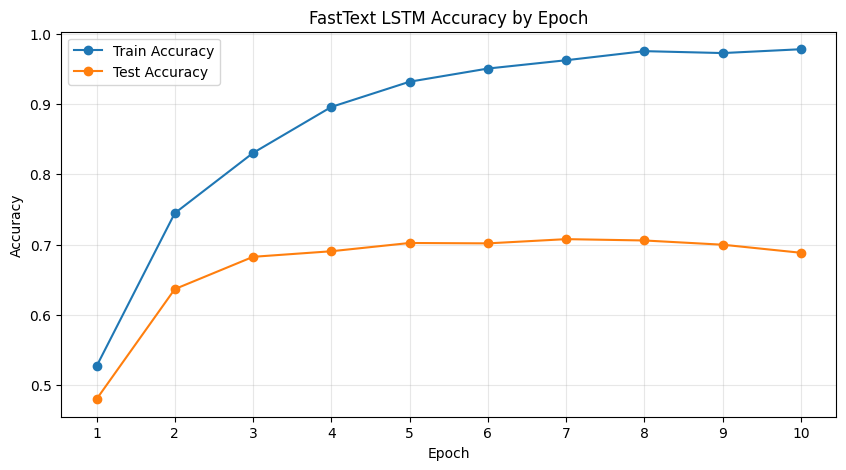

In [41]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, fasttext_train_accuracies, marker='o', label="Train Accuracy")
plt.plot(epochs, fasttext_test_accuracies, marker='o', label="Test Accuracy")

plt.title("FastText LSTM Accuracy by Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

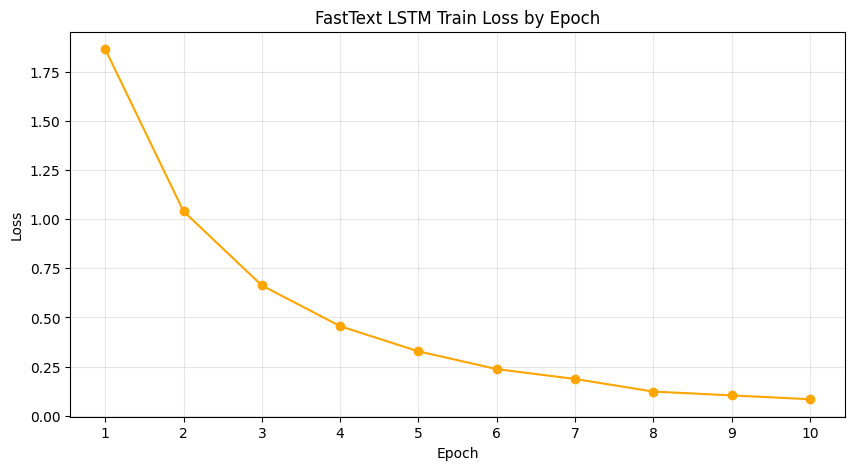

In [42]:
plt.figure(figsize=(10, 5))
plt.plot(epochs, fasttext_train_losses, marker='o', color='orange')

plt.title("FastText LSTM Train Loss by Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.grid(alpha=0.3)
plt.show()

### 평가 지표

In [43]:
y_true_fasttext, y_pred_fasttext = get_predictions(
    model_fasttext,
    test_loader_fasttext,
    device
)

In [44]:
fasttext_accuracy = accuracy_score(y_true_fasttext, y_pred_fasttext)
fasttext_macro_precision = precision_score(y_true_fasttext, y_pred_fasttext, average='macro', zero_division=0)
fasttext_macro_recall = recall_score(y_true_fasttext, y_pred_fasttext, average='macro', zero_division=0)
fasttext_macro_f1 = f1_score(y_true_fasttext, y_pred_fasttext, average='macro', zero_division=0)

fasttext_weighted_precision = precision_score(y_true_fasttext, y_pred_fasttext, average='weighted', zero_division=0)
fasttext_weighted_recall = recall_score(y_true_fasttext, y_pred_fasttext, average='weighted', zero_division=0)
fasttext_weighted_f1 = f1_score(y_true_fasttext, y_pred_fasttext, average='weighted', zero_division=0)

print(f"Accuracy          : {fasttext_accuracy:.4f}")
print(f"Macro Precision   : {fasttext_macro_precision:.4f}")
print(f"Macro Recall      : {fasttext_macro_recall:.4f}")
print(f"Macro F1          : {fasttext_macro_f1:.4f}")
print(f"Weighted Precision: {fasttext_weighted_precision:.4f}")
print(f"Weighted Recall   : {fasttext_weighted_recall:.4f}")
print(f"Weighted F1       : {fasttext_weighted_f1:.4f}")

Accuracy          : 0.6882
Macro Precision   : 0.6940
Macro Recall      : 0.6788
Macro F1          : 0.6809
Weighted Precision: 0.7057
Weighted Recall   : 0.6882
Weighted F1       : 0.6915


In [45]:
target_names = news_data.target_names

print(classification_report(
    y_true_fasttext,
    y_pred_fasttext,
    target_names=target_names,
    zero_division=0
))

                          precision    recall  f1-score   support

             alt.atheism       0.67      0.47      0.55       170
           comp.graphics       0.73      0.63      0.68       189
 comp.os.ms-windows.misc       0.66      0.66      0.66       179
comp.sys.ibm.pc.hardware       0.66      0.56      0.60       198
   comp.sys.mac.hardware       0.64      0.70      0.67       183
          comp.windows.x       0.85      0.80      0.83       199
            misc.forsale       0.60      0.74      0.66       175
               rec.autos       0.72      0.67      0.70       202
         rec.motorcycles       0.80      0.73      0.76       205
      rec.sport.baseball       0.91      0.75      0.82       206
        rec.sport.hockey       0.80      0.90      0.85       191
               sci.crypt       0.84      0.70      0.77       184
         sci.electronics       0.41      0.73      0.53       179
                 sci.med       0.85      0.73      0.79       177
         

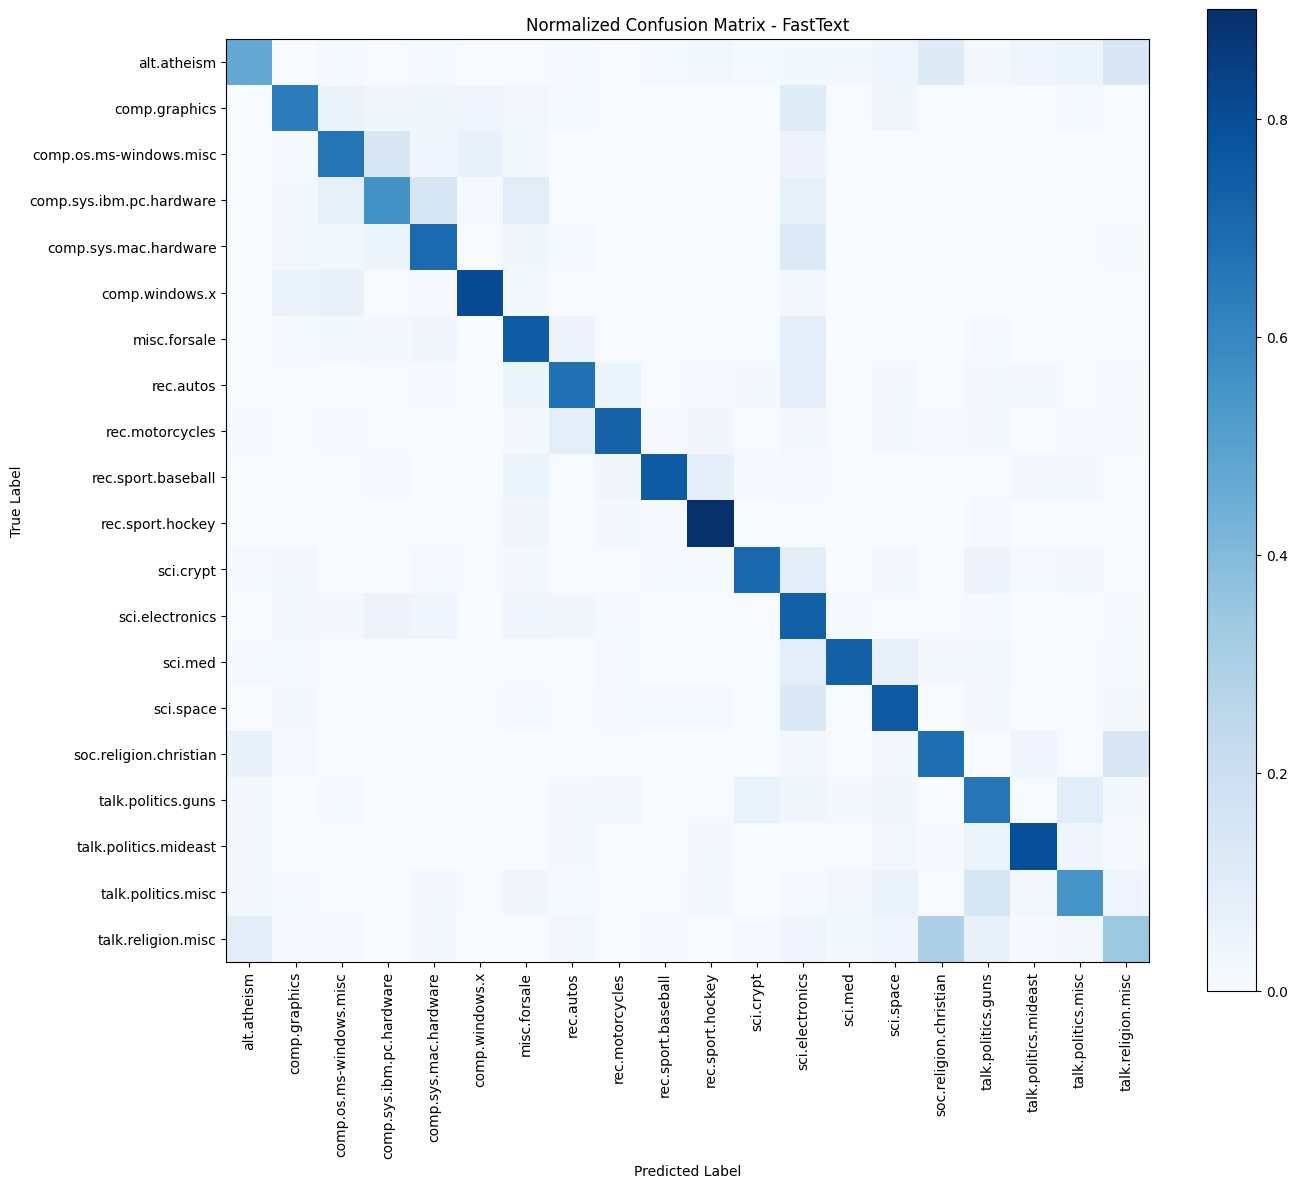

In [46]:
cm = confusion_matrix(y_true_fasttext, y_pred_fasttext)

cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)

plt.figure(figsize=(14, 12))
plt.imshow(cm_norm, interpolation='nearest', cmap='Blues')
plt.title("Normalized Confusion Matrix - FastText")
plt.colorbar()

tick_marks = np.arange(len(target_names))
plt.xticks(tick_marks, target_names, rotation=90)
plt.yticks(tick_marks, target_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [64]:
for sample_idx in range(5):
    pred_idx, pred_label, pred_prob, cleaned_text = predict_one_text(
        test_inputs[sample_idx],
        model_fasttext,
        word2idx_fasttext,
        max_len,
        news_data.target_names,
        device,
        already_cleaned=True,
        unk_idx=UNK_IDX,
        pad_idx=PAD_IDX
    )

    true_label = news_data.target_names[test_targets[sample_idx]]

    print(f"[테스트 샘플 {sample_idx}]")
    print(f"실제 라벨: {true_label}")
    print(f"예측 라벨: {pred_label}")
    print(f"확신도: {pred_prob:.4f}")
    print("전처리된 텍스트:")
    print(cleaned_text[:500])
    print("-" * 80)


[테스트 샘플 0]
실제 라벨: talk.politics.mideast
예측 라벨: talk.politics.mideast
확신도: 0.9996
전처리된 텍스트:
andi beyer responds talk generalizations indeed sound quite immature aclu fighting anti hate law mean aclu would support gay bashing racial discrimination anti semitic violence thanks andi reminding us constitution preserves rights fun activities probably galileo happened right jews offended holocaust deniers revisionists deny history even happened happen wrong
--------------------------------------------------------------------------------
[테스트 샘플 1]
실제 라벨: sci.med
예측 라벨: sci.med
확신도: 0.9928
전처리된 텍스트:
seen children wondered something mucus one nose collects filters particles going airway child picks ingests material might vaccinatory effect since body ingests airborne diseases stuff mucus body might generate antibodies small invasion maybe children get sick often tom
--------------------------------------------------------------------------------
[테스트 샘플 2]
실제 라벨: talk.religion.misc
예측 라벨: soc.r

## GloVe

In [47]:
import os
import urllib.request
import zipfile

# GloVe 다운로드 및 임베딩 로드
GLOVE_URL = "https://nlp.stanford.edu/data/glove.6B.zip"
GLOVE_ZIP = "glove.6B.zip"
GLOVE_FILE = "glove.6B.200d.txt"

if not os.path.exists(GLOVE_FILE):
    print("Downloading GloVe embeddings...")
    urllib.request.urlretrieve(GLOVE_URL, GLOVE_ZIP)

    with zipfile.ZipFile(GLOVE_ZIP, 'r') as zip_ref:
        zip_ref.extractall()

    print("GloVe embeddings downloaded and extracted.")
else:
    print("GloVe embeddings already available.")

GloVe embeddings downloaded and extracted.


In [48]:
glove_dim = 200
glove_embeddings = {}

with open(GLOVE_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coeffs = np.asarray(values[1:], dtype='float32')
        glove_embeddings[word] = coeffs

print("GloVe vocab size:", len(glove_embeddings))

GloVe vocab size: 400000


In [49]:
# train 데이터 기준 vocab 생성
train_vocab = sorted(set(token for sentence in train_sentences for token in sentence))

# 전처리에서 만든 특수토큰은 GloVe에 없을 가능성이 높으므로 직접 포함
custom_special_tokens = ["urltoken", "emailtoken", "numtoken"]

# PAD/UNK는 index 예약
word2idx_glove = {
    "PADTOKEN": PAD_IDX,
    "UNKTOKEN": UNK_IDX
}

current_idx = 2

# 사용자 정의 특수토큰 먼저 추가
for token in custom_special_tokens:
    if token not in word2idx_glove:
        word2idx_glove[token] = current_idx
        current_idx += 1

# train vocab 중 GloVe에 있는 단어만 추가
for word in train_vocab:
    if word in word2idx_glove:
        continue

    if word in glove_embeddings:
        word2idx_glove[word] = current_idx
        current_idx += 1

print("Train vocab size:", len(train_vocab))
print("GloVe word2idx size:", len(word2idx_glove))

Train vocab size: 75584
GloVe word2idx size: 50916


In [50]:
# GloVe embedding matrix 생성
glove_matrix = np.zeros((len(word2idx_glove), glove_dim))

# UNK는 랜덤 벡터로 초기화
glove_matrix[UNK_IDX] = np.random.normal(0, 0.1, glove_dim)

# 사용자 정의 특수토큰도 랜덤 벡터로 초기화
for token in custom_special_tokens:
    idx = word2idx_glove[token]
    glove_matrix[idx] = np.random.normal(0, 0.1, glove_dim)

# GloVe에 있는 단어는 사전학습 벡터 사용
for word, idx in word2idx_glove.items():
    if word in ["PADTOKEN", "UNKTOKEN"] + custom_special_tokens:
        continue

    glove_matrix[idx] = glove_embeddings[word]

In [51]:
# GloVe Dataset
train_dataset_glove = TextEmbeddingDataset(
    train_inputs,
    train_targets,
    word2idx_glove,
    max_len,
    unk_idx=UNK_IDX,
    pad_idx=PAD_IDX
)

test_dataset_glove = TextEmbeddingDataset(
    test_inputs,
    test_targets,
    word2idx_glove,
    max_len,
    unk_idx=UNK_IDX,
    pad_idx=PAD_IDX
)

# GloVe DataLoader
train_loader_glove = DataLoader(
    train_dataset_glove,
    batch_size=64,
    sampler=weighted_sampler
)

test_loader_glove = DataLoader(
    test_dataset_glove,
    batch_size=64,
    shuffle=False
)

In [52]:
model_glove = EmbeddingLSTM(glove_matrix, hidden_dim, output_dim).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_glove.parameters(), lr=0.005)

num_epochs = 10

glove_train_losses = []
glove_train_accuracies = []
glove_test_accuracies = []

for epoch in range(num_epochs):
    loss = train(model_glove, train_loader_glove, loss_fn, optimizer)

    train_acc = evaluate(model_glove, train_loader_glove)
    test_acc = evaluate(model_glove, test_loader_glove)

    glove_train_losses.append(loss)
    glove_train_accuracies.append(train_acc)
    glove_test_accuracies.append(test_acc)

    print(
        f"Epoch {epoch+1}, "
        f"Loss: {loss:.4f}, "
        f"Train Accuracy: {train_acc:.4f}, "
        f"Test Accuracy: {test_acc:.4f}"
    )

Epoch 1, Loss: 1.6981, Train Accuracy: 0.6113, Test Accuracy: 0.5543
Epoch 2, Loss: 0.8842, Train Accuracy: 0.8072, Test Accuracy: 0.6745
Epoch 3, Loss: 0.5371, Train Accuracy: 0.8812, Test Accuracy: 0.7038
Epoch 4, Loss: 0.3619, Train Accuracy: 0.9198, Test Accuracy: 0.7013
Epoch 5, Loss: 0.2471, Train Accuracy: 0.9417, Test Accuracy: 0.7065
Epoch 6, Loss: 0.1908, Train Accuracy: 0.9594, Test Accuracy: 0.7128
Epoch 7, Loss: 0.1357, Train Accuracy: 0.9720, Test Accuracy: 0.7120
Epoch 8, Loss: 0.1081, Train Accuracy: 0.9781, Test Accuracy: 0.7131
Epoch 9, Loss: 0.0963, Train Accuracy: 0.9816, Test Accuracy: 0.7106
Epoch 10, Loss: 0.0702, Train Accuracy: 0.9808, Test Accuracy: 0.7008


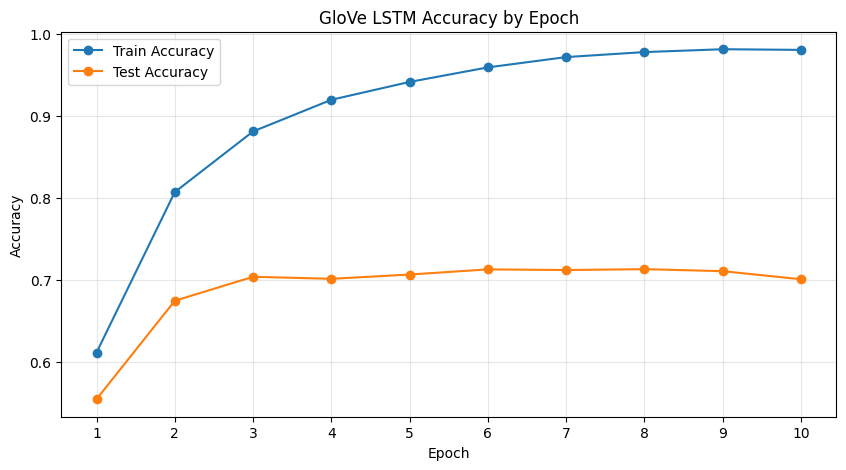

In [53]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, glove_train_accuracies, marker='o', label="Train Accuracy")
plt.plot(epochs, glove_test_accuracies, marker='o', label="Test Accuracy")

plt.title("GloVe LSTM Accuracy by Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

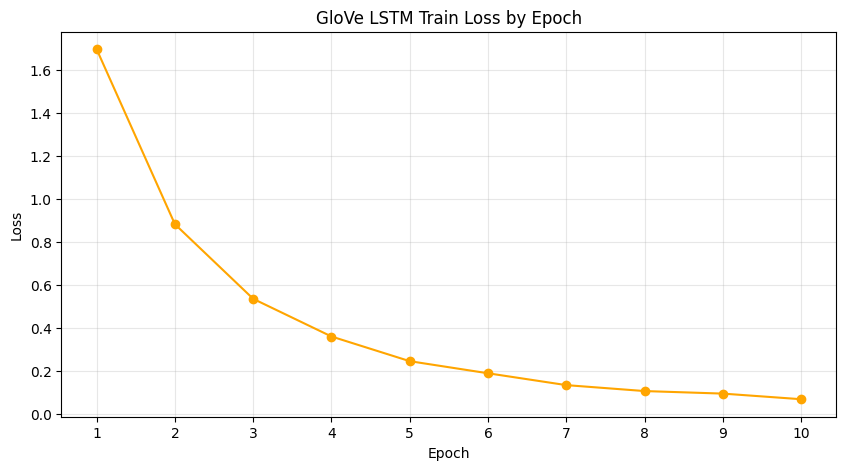

In [54]:
plt.figure(figsize=(10, 5))
plt.plot(epochs, glove_train_losses, marker='o', color='orange')

plt.title("GloVe LSTM Train Loss by Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.grid(alpha=0.3)
plt.show()

### 평가 지표

In [55]:
y_true_glove, y_pred_glove = get_predictions(
    model_glove,
    test_loader_glove,
    device
)

In [56]:
glove_accuracy = accuracy_score(y_true_glove, y_pred_glove)
glove_macro_precision = precision_score(y_true_glove, y_pred_glove, average='macro', zero_division=0)
glove_macro_recall = recall_score(y_true_glove, y_pred_glove, average='macro', zero_division=0)
glove_macro_f1 = f1_score(y_true_glove, y_pred_glove, average='macro', zero_division=0)

glove_weighted_precision = precision_score(y_true_glove, y_pred_glove, average='weighted', zero_division=0)
glove_weighted_recall = recall_score(y_true_glove, y_pred_glove, average='weighted', zero_division=0)
glove_weighted_f1 = f1_score(y_true_glove, y_pred_glove, average='weighted', zero_division=0)

print(f"Accuracy          : {glove_accuracy:.4f}")
print(f"Macro Precision   : {glove_macro_precision:.4f}")
print(f"Macro Recall      : {glove_macro_recall:.4f}")
print(f"Macro F1          : {glove_macro_f1:.4f}")
print(f"Weighted Precision: {glove_weighted_precision:.4f}")
print(f"Weighted Recall   : {glove_weighted_recall:.4f}")
print(f"Weighted F1       : {glove_weighted_f1:.4f}")

Accuracy          : 0.7008
Macro Precision   : 0.7016
Macro Recall      : 0.6920
Macro F1          : 0.6936
Weighted Precision: 0.7131
Weighted Recall   : 0.7008
Weighted F1       : 0.7038


In [57]:
target_names = news_data.target_names

print(classification_report(
    y_true_glove,
    y_pred_glove,
    target_names=target_names,
    zero_division=0
))

                          precision    recall  f1-score   support

             alt.atheism       0.58      0.53      0.55       170
           comp.graphics       0.61      0.64      0.63       189
 comp.os.ms-windows.misc       0.66      0.66      0.66       179
comp.sys.ibm.pc.hardware       0.60      0.73      0.65       198
   comp.sys.mac.hardware       0.79      0.61      0.69       183
          comp.windows.x       0.90      0.72      0.80       199
            misc.forsale       0.64      0.77      0.70       175
               rec.autos       0.63      0.71      0.67       202
         rec.motorcycles       0.75      0.72      0.73       205
      rec.sport.baseball       0.90      0.78      0.84       206
        rec.sport.hockey       0.90      0.87      0.89       191
               sci.crypt       0.80      0.76      0.78       184
         sci.electronics       0.62      0.65      0.64       179
                 sci.med       0.81      0.86      0.84       177
         

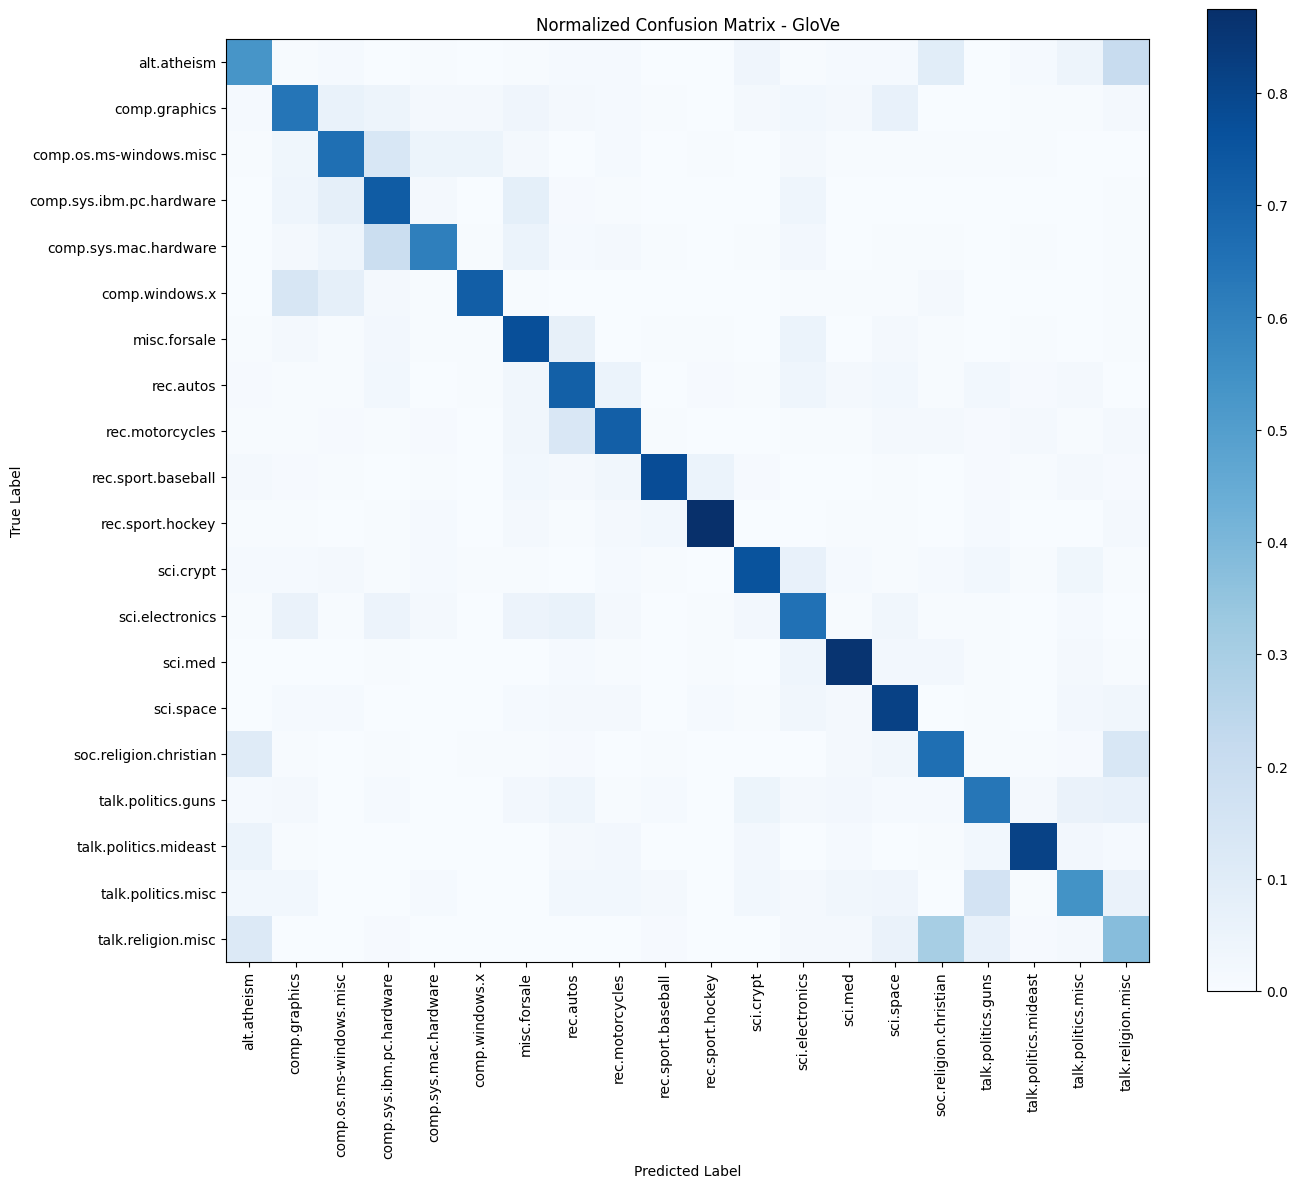

In [58]:
cm = confusion_matrix(y_true_glove, y_pred_glove)

cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)

plt.figure(figsize=(14, 12))
plt.imshow(cm_norm, interpolation='nearest', cmap='Blues')
plt.title("Normalized Confusion Matrix - GloVe")
plt.colorbar()

tick_marks = np.arange(len(target_names))
plt.xticks(tick_marks, target_names, rotation=90)
plt.yticks(tick_marks, target_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [65]:
for sample_idx in range(5):
    pred_idx, pred_label, pred_prob, cleaned_text = predict_one_text(
        test_inputs[sample_idx],
        model_glove,
        word2idx_glove,
        max_len,
        news_data.target_names,
        device,
        already_cleaned=True,
        unk_idx=UNK_IDX,
        pad_idx=PAD_IDX
    )

    true_label = news_data.target_names[test_targets[sample_idx]]

    print(f"[테스트 샘플 {sample_idx}]")
    print(f"실제 라벨: {true_label}")
    print(f"예측 라벨: {pred_label}")
    print(f"확신도: {pred_prob:.4f}")
    print("전처리된 텍스트:")
    print(cleaned_text[:500])
    print("-" * 80)


[테스트 샘플 0]
실제 라벨: talk.politics.mideast
예측 라벨: talk.politics.mideast
확신도: 0.9998
전처리된 텍스트:
andi beyer responds talk generalizations indeed sound quite immature aclu fighting anti hate law mean aclu would support gay bashing racial discrimination anti semitic violence thanks andi reminding us constitution preserves rights fun activities probably galileo happened right jews offended holocaust deniers revisionists deny history even happened happen wrong
--------------------------------------------------------------------------------
[테스트 샘플 1]
실제 라벨: sci.med
예측 라벨: sci.med
확신도: 0.9996
전처리된 텍스트:
seen children wondered something mucus one nose collects filters particles going airway child picks ingests material might vaccinatory effect since body ingests airborne diseases stuff mucus body might generate antibodies small invasion maybe children get sick often tom
--------------------------------------------------------------------------------
[테스트 샘플 2]
실제 라벨: talk.religion.misc
예측 라벨: talk.

# 모델 결과 비교

In [71]:
comparison_df = pd.DataFrame([
    {
        "model": "Word2Vec",
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1
    },
    {
        "model": "FastText",
        "accuracy": fasttext_accuracy,
        "macro_precision": fasttext_macro_precision,
        "macro_recall": fasttext_macro_recall,
        "macro_f1": fasttext_macro_f1,
        "weighted_precision": fasttext_weighted_precision,
        "weighted_recall": fasttext_weighted_recall,
        "weighted_f1": fasttext_weighted_f1
    },
    {
        "model": "GloVe",
        "accuracy": glove_accuracy,
        "macro_precision": glove_macro_precision,
        "macro_recall": glove_macro_recall,
        "macro_f1": glove_macro_f1,
        "weighted_precision": glove_weighted_precision,
        "weighted_recall": glove_weighted_recall,
        "weighted_f1": glove_weighted_f1
    }
])

comparison_df = comparison_df.sort_values("accuracy", ascending=False)

comparison_df.round(4)


,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
2,GloVe,0.7008,0.7016,0.6920,0.6936,0.7131,0.7008,0.7038
0,Word2Vec,0.6992,0.7053,0.6953,0.6937,0.7165,0.6992,0.7020
1,FastText,0.6882,0.6940,0.6788,0.6809,0.7057,0.6882,0.6915


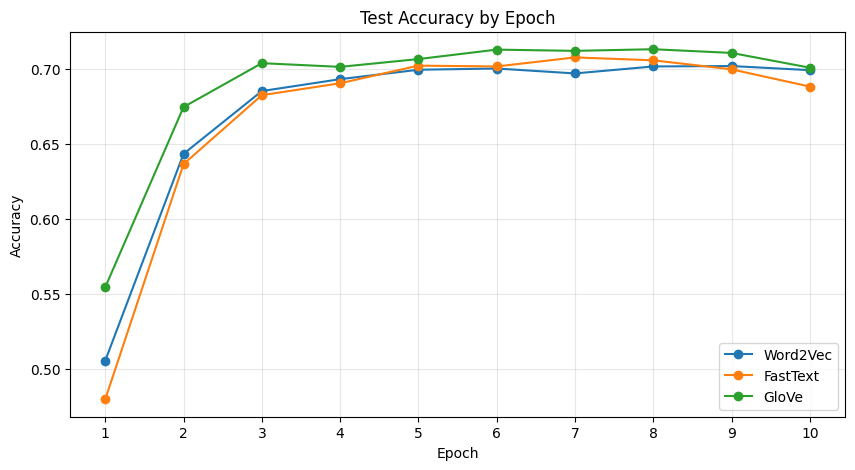

In [68]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(10, 5))

plt.plot(epochs, test_accuracies, marker='o', label="Word2Vec")
plt.plot(epochs, fasttext_test_accuracies, marker='o', label="FastText")
plt.plot(epochs, glove_test_accuracies, marker='o', label="GloVe")

plt.title("Test Accuracy by Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [72]:
from sklearn.metrics import precision_recall_fscore_support

_, _, f1_w2v, support = precision_recall_fscore_support(
    y_true_w2v,
    y_pred_w2v,
    zero_division=0
)

_, _, f1_fasttext, _ = precision_recall_fscore_support(
    y_true_fasttext,
    y_pred_fasttext,
    zero_division=0
)

_, _, f1_glove, _ = precision_recall_fscore_support(
    y_true_glove,
    y_pred_glove,
    zero_division=0
)

class_f1_df = pd.DataFrame({
    "class": news_data.target_names,
    "support": support,
    "Word2Vec_f1": f1_w2v,
    "FastText_f1": f1_fasttext,
    "GloVe_f1": f1_glove
})

class_f1_df = class_f1_df.sort_values("GloVe_f1", ascending=True)

class_f1_df.round(4)


,class,support,Word2Vec_f1,FastText_f1,GloVe_f1
19,talk.religion.misc,109,0.4026,0.3304,0.3203
0,alt.atheism,170,0.5539,0.5536,0.5538
18,talk.politics.misc,163,0.5995,0.5825,0.5867
1,comp.graphics,189,0.6720,0.6799,0.6253
12,sci.electronics,179,0.6250,0.5293,0.6359
16,talk.politics.guns,176,0.6007,0.6322,0.6455
3,comp.sys.ibm.pc.hardware,198,0.6169,0.6049,0.6545
15,soc.religion.christian,200,0.5808,0.6834,0.6584
2,comp.os.ms-windows.misc,179,0.7018,0.6630,0.6592
7,rec.autos,202,0.7537,0.6957,0.6682


## 다음 작업 메모

### 현재 결과 요약
- 같은 전처리, 같은 LSTM 구조, 같은 epoch 기준으로 Word2Vec, FastText, GloVe를 비교했다.
- 현재 accuracy 기준으로는 GloVe가 가장 높고, Word2Vec이 거의 비슷하며, FastText가 약간 낮다.
- 핵심 지표는 accuracy만 보지 말고 macro F1을 같이 보는 것이 좋다. 클래스 수가 20개이고 일부 클래스가 적기 때문이다.

### 현재 낮은 클래스
- GloVe 기준으로 `talk.religion.misc`의 F1이 가장 낮다.
- `alt.atheism`, `talk.politics.misc`, `comp.graphics`, `sci.electronics`도 상대적으로 낮은 편이다.
- 특히 `talk.religion.misc`는 Word2Vec, FastText, GloVe 모두에서 낮게 나와 공통적으로 어려운 클래스다.

### 낮은 점수의 가능한 이유
- `talk.religion.misc`는 train/test support가 상대적으로 적어서 학습 신호가 부족할 수 있다.
- `talk.religion.misc`, `alt.atheism`, `soc.religion.christian`은 `god`, `religion`, `christian`, `belief` 같은 단어가 겹쳐서 모델이 헷갈리기 쉽다.
- 전처리 후 상위 빈출 단어에 `NUMTOKEN`, `ax`, `x`, `q`, `g`, `f` 같은 노이즈성 토큰이 많이 남아 있다.
- train accuracy는 높게 올라가는데 test accuracy는 0.70 근처에서 정체되어 과적합 가능성이 있다.

### 다음에 먼저 할 일
- GloVe의 custom special token 대소문자를 전처리 결과와 맞추기. 현재 전처리 결과는 `NUMTOKEN`, `EMAILTOKEN`처럼 대문자로 남을 수 있는데 GloVe 코드에서는 `numtoken`, `emailtoken`처럼 소문자로 추가되어 있어 불일치 가능성이 있다.
- 전처리 함수에서 special token을 처음부터 소문자로 넣는 방식으로 통일하는 것을 추천한다. 예: `urltoken`, `emailtoken`, `numtoken`.
- `ax`, 한 글자 토큰 등 의미 없는 빈출 토큰을 사용자 정의 stopword로 제거할지 실험한다.
- `NUMTOKEN`이 너무 많이 등장하므로 숫자를 `numtoken`으로 치환할지, 아예 제거할지 비교 실험한다.
- 마지막 epoch 모델을 무조건 쓰지 말고, validation 성능이 가장 좋은 epoch을 저장하는 방식으로 바꾸는 것을 고려한다.

### 비교 기준 유지
- 세 모델 비교 시 전처리, `max_len`, batch size, optimizer, learning rate, epoch 수, sampler 사용 여부는 동일하게 유지한다.
- 최종 비교는 `macro_f1`을 중심으로 보고, `accuracy`와 `weighted_f1`은 보조 지표로 같이 확인한다.
